Table 1. Dataset Summary Table for the Ames Housing Dataset
                           Metric  Value
0          Number of observations   2919
1             Number of variables     81
2    Number of numerical features     38
3  Number of categorical features     43
4            Total missing values  17166


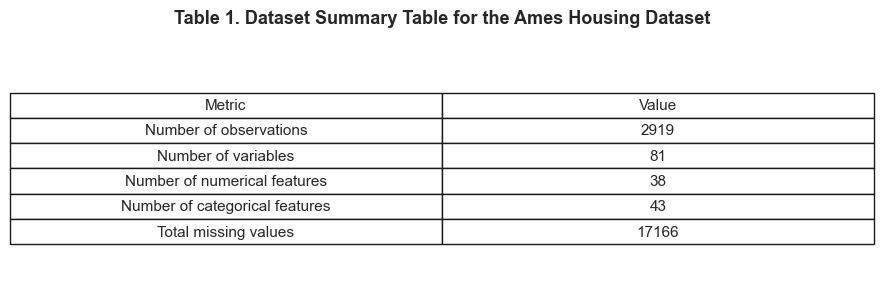

Skewness of SalePrice: 1.883


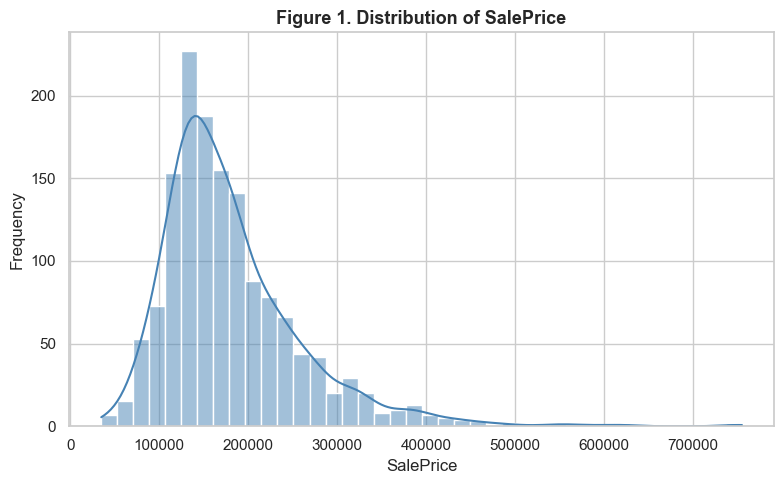

Skewness of log-transformed SalePrice: 0.121


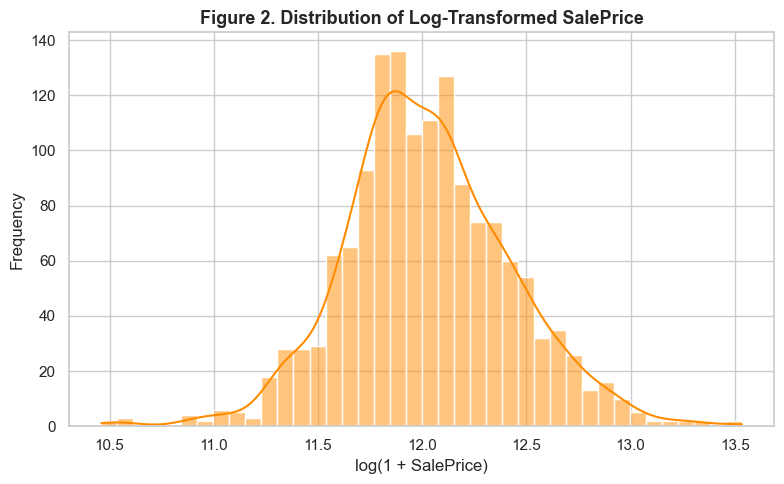

Table 2. Missing Value Counts and Percentages
         Feature  Missing Values  Missing Percentage (%)
0         PoolQC            2909                   99.66
1    MiscFeature            2814                   96.40
2          Alley            2721                   93.22
3          Fence            2348                   80.44
4     MasVnrType            1766                   60.50
5      SalePrice            1459                   49.98
6    FireplaceQu            1420                   48.65
7    LotFrontage             486                   16.65
8     GarageCond             159                    5.45
9    GarageYrBlt             159                    5.45
10  GarageFinish             159                    5.45
11    GarageQual             159                    5.45
12    GarageType             157                    5.38
13  BsmtExposure              82                    2.81
14      BsmtCond              82                    2.81
15      BsmtQual              81          

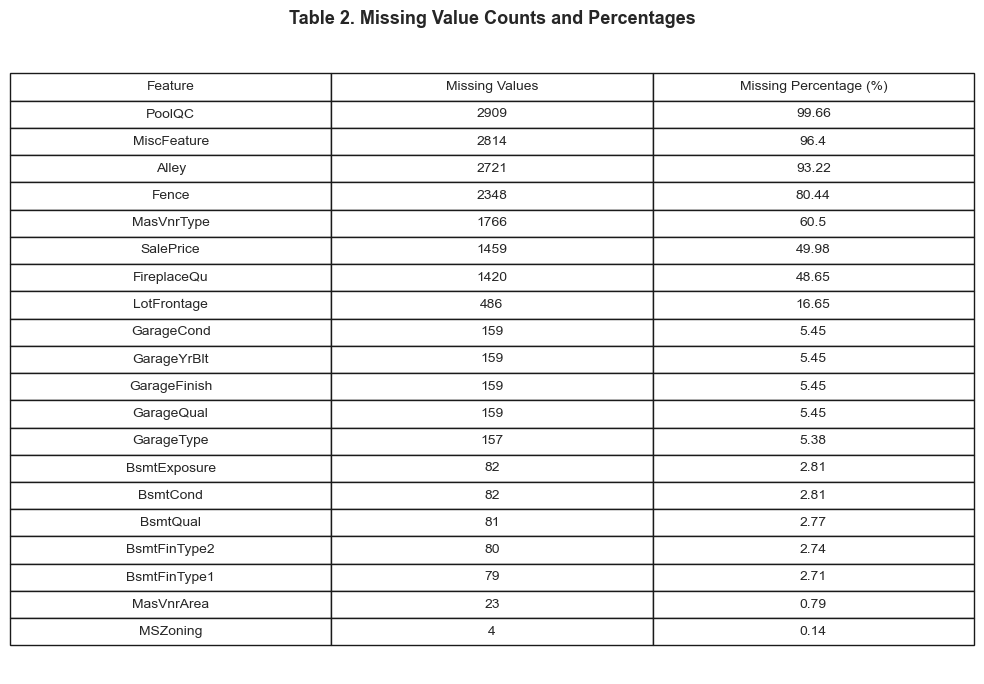

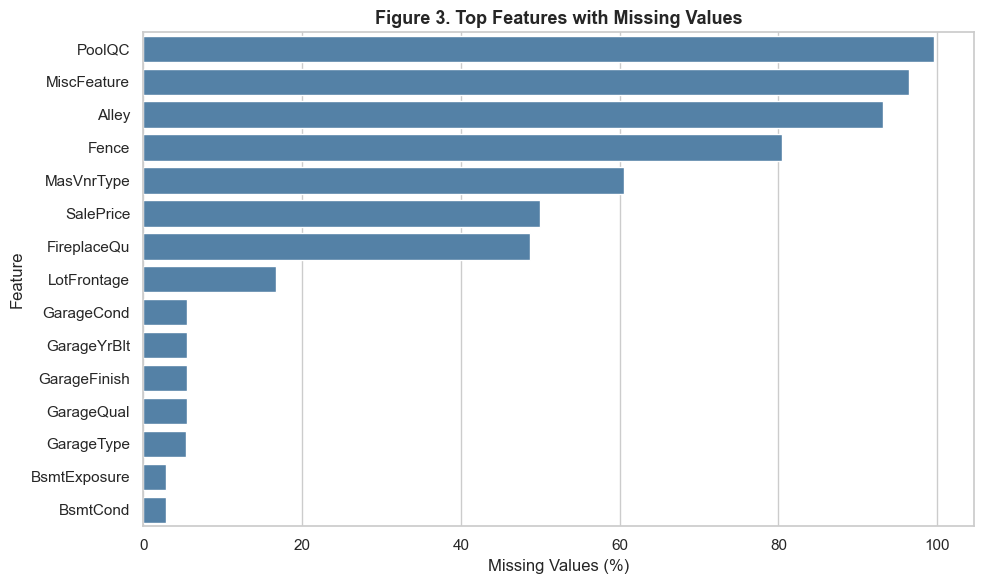

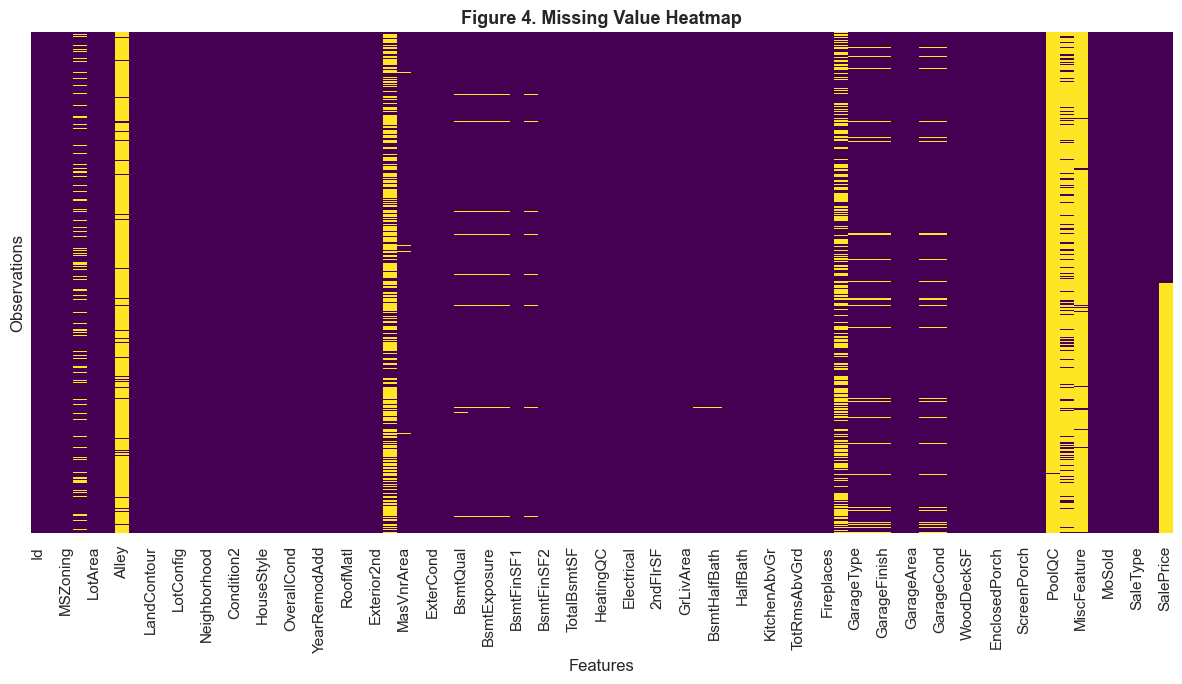

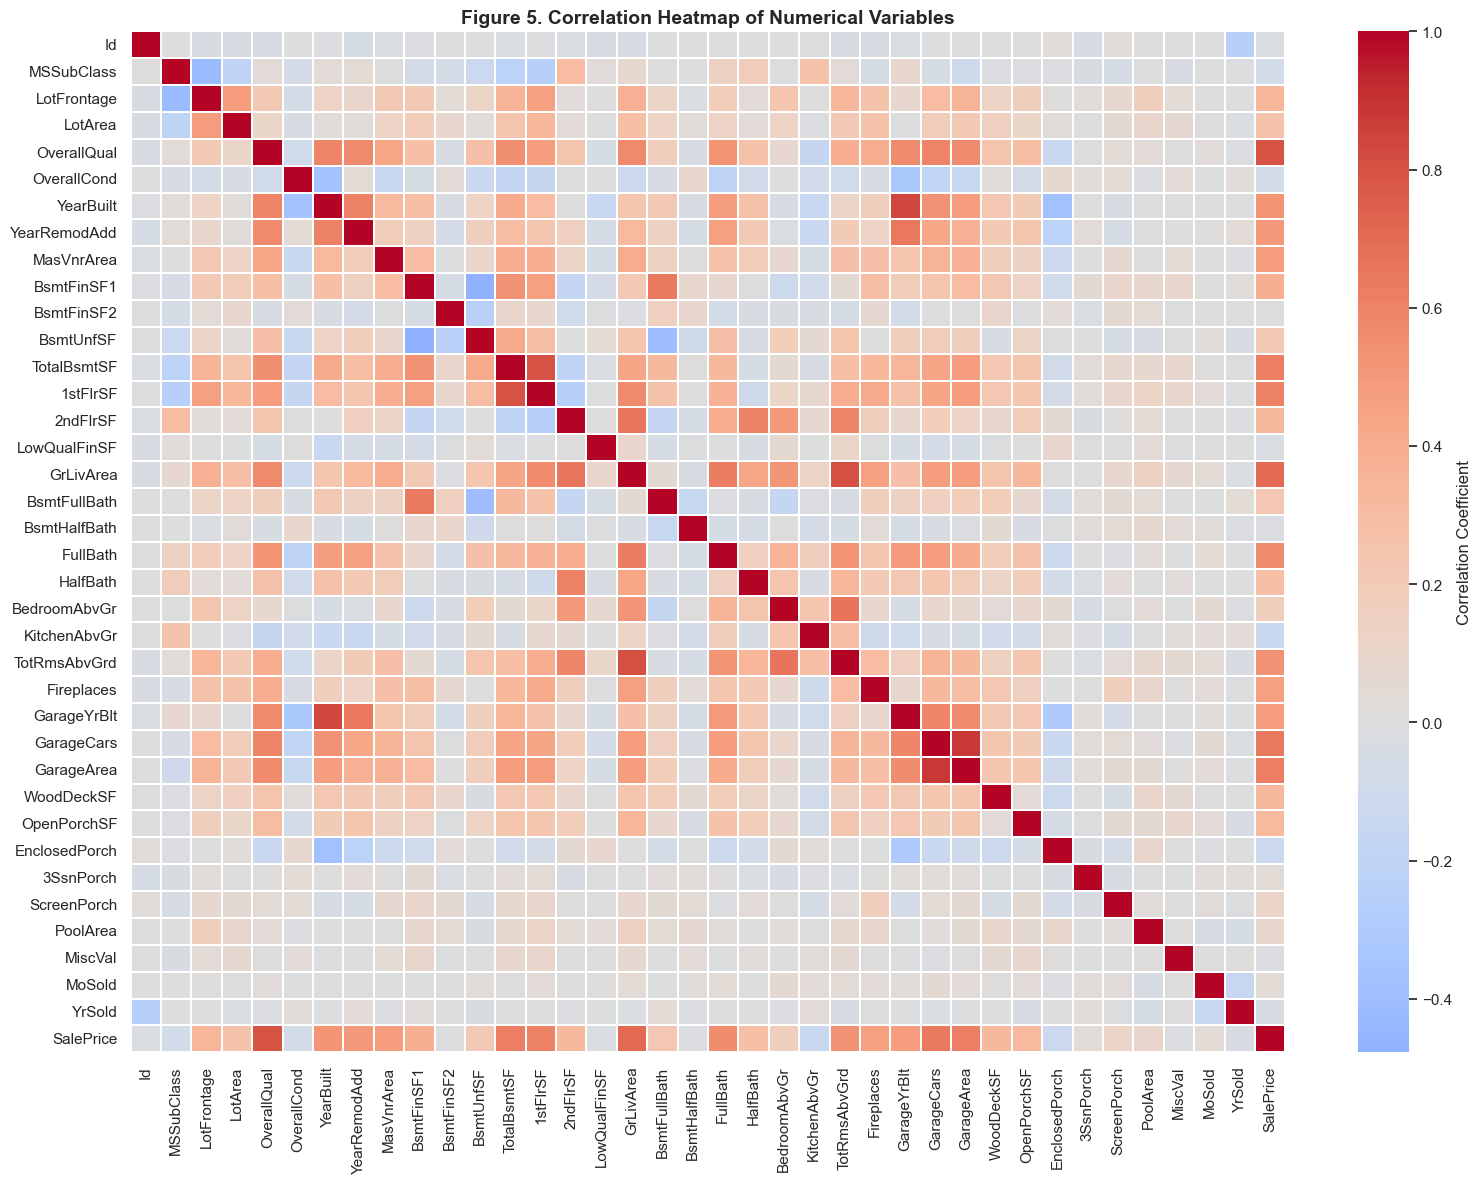

Top 10 numerical features most correlated with SalePrice:
        Feature  Correlation with SalePrice
0   OverallQual                    0.790982
1     GrLivArea                    0.708624
2    GarageCars                    0.640409
3    GarageArea                    0.623431
4   TotalBsmtSF                    0.613581
5      1stFlrSF                    0.605852
6      FullBath                    0.560664
7  TotRmsAbvGrd                    0.533723
8     YearBuilt                    0.522897
9  YearRemodAdd                    0.507101


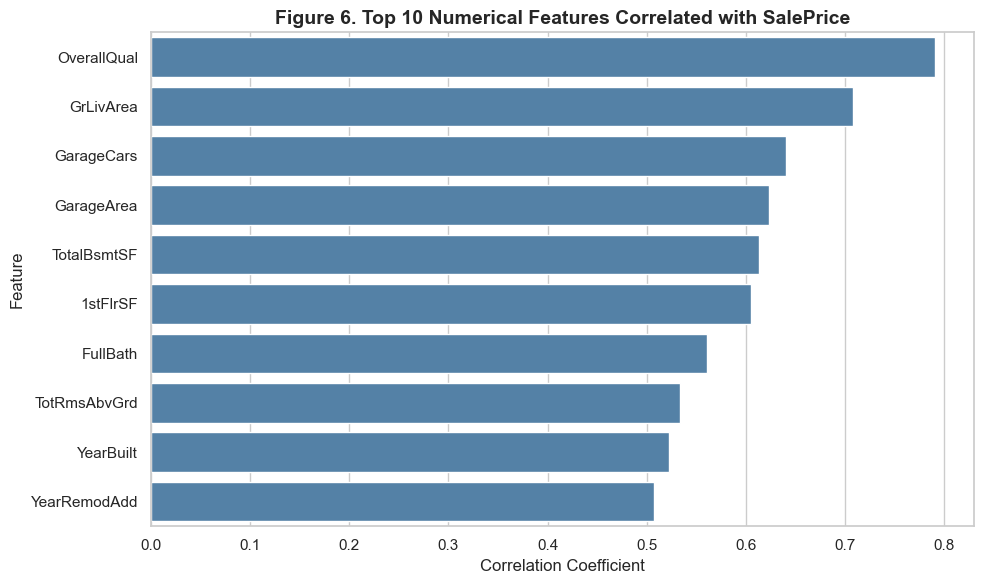

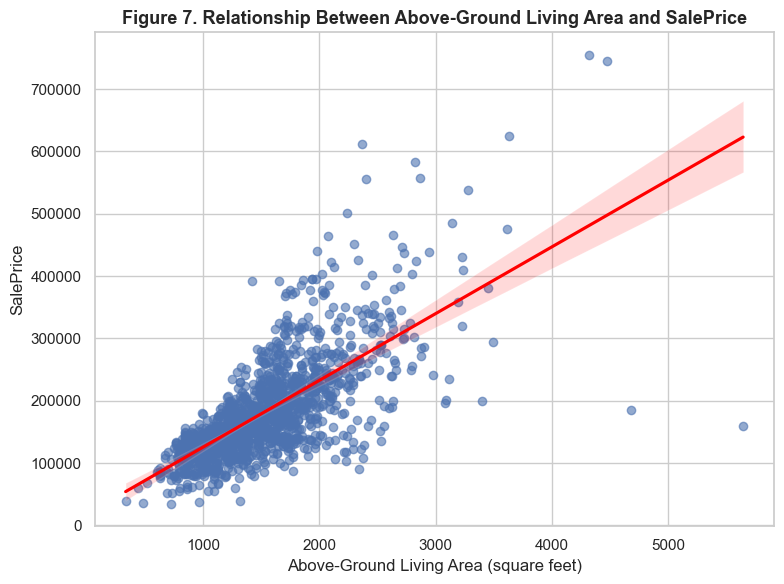

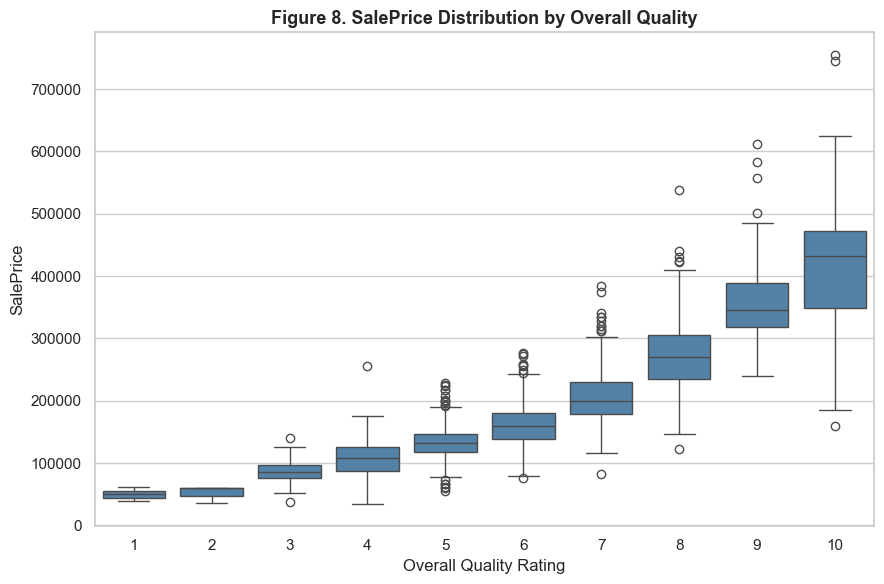

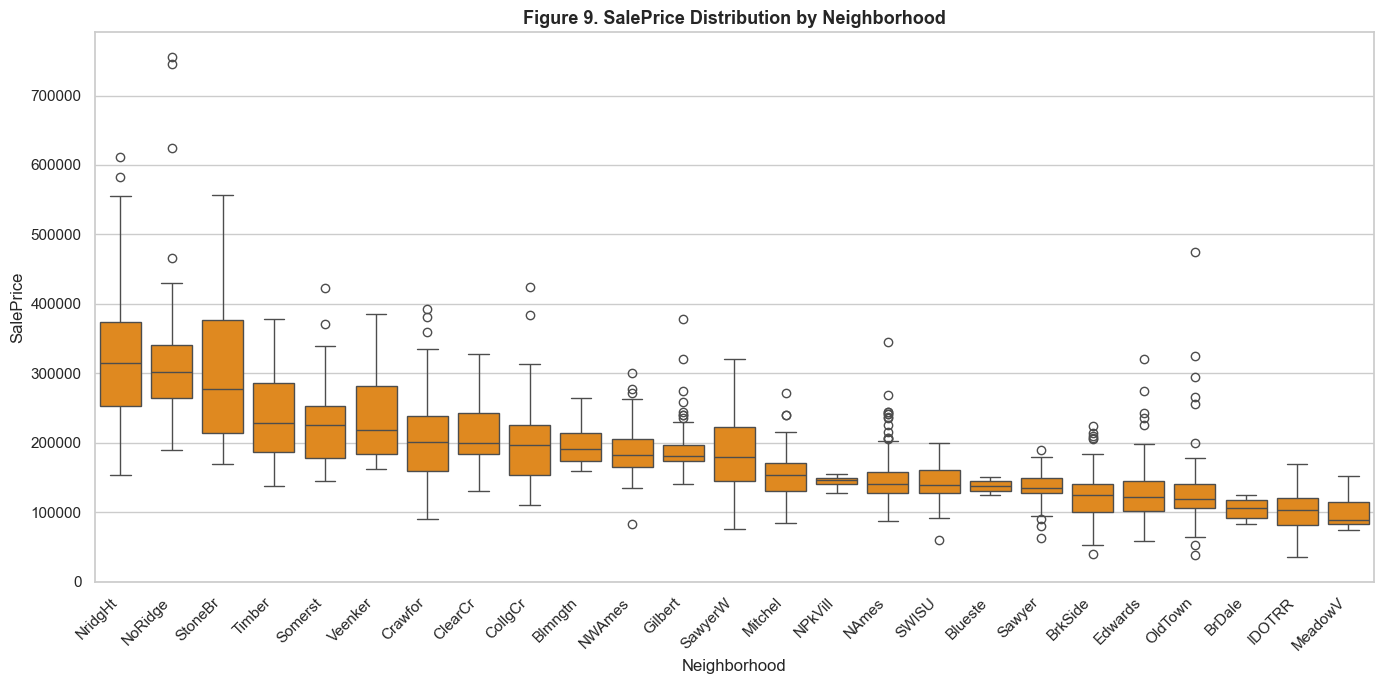

--- Best Hyperparameters Found ---
Best Ridge Alpha: {'model__alpha': 10.0}
Best Lasso Alpha: {'model__alpha': 0.0005}
Best Random Forest Params: {'model__max_depth': 20, 'model__n_estimators': 300}
Best XGBoost Params: {'model__learning_rate': 0.1, 'model__max_depth': 3}

--- Validation Performance Metrics ---
[OLS/Ridge] RMSE: 0.1229 | MAE: 0.0860 | R2: 0.9105
[Lasso] RMSE: 0.1171 | MAE: 0.0839 | R2: 0.9186
[Random Forest] RMSE: 0.1439 | MAE: 0.0968 | R2: 0.8772
[XGBoost] RMSE: 0.1197 | MAE: 0.0877 | R2: 0.9150

# Best model

Best model:
Model       Lasso
RMSE     0.117138
MAE      0.083855
R2       0.918605
Name: 0, dtype: object

Summary Evaluation Matrix:
           Model      RMSE       MAE        R2
0          Lasso  0.117138  0.083855  0.918605
1        XGBoost  0.119677  0.087701  0.915037
2      OLS/Ridge  0.122860  0.086024  0.910458
3  Random Forest  0.143861  0.096849  0.877232


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set uniform visual style for all plots to ensure professional, matching report aesthetics
sns.set_theme(style="whitegrid")

# Define global dataset path (Ensure data.csv is present in this working directory)
data_path = "data.csv"
df = pd.read_csv(data_path)

# ==============================================================================
# SECTION 2: DATASET DESCRIPTION & EXPLORATORY DATA ANALYSIS (EDA) [NEW ADDITIONS]
# ==============================================================================

# --- 2.1 Dataset Summary Table ---
# Isolate feature names based on data types to understand structural breakdown
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.select_dtypes(include=["object", "category"]).columns

# Compile baseline dataset properties into a structured summary DataFrame for Chapter 2.1
summary_table = pd.DataFrame({
    "Metric": [
        "Number of observations",        # Total rows (sample size)
        "Number of variables",           # Total columns (features + target)
        "Number of numerical features",  # Count of continuous/discrete numeric dimensions
        "Number of categorical features",# Count of nominal/ordinal textual string dimensions
        "Total missing values"           # Sum total of all null/NaN entries across the matrix
    ],
    "Value": [
        df.shape[0],                     # Row dimension length
        df.shape[1],                     # Column dimension length
        len(numerical_features),         # Quantitative count
        len(categorical_features),       # Qualitative count
        df.isnull().sum().sum()          # Double-summation to collapse missing flags to an absolute integer
    ]
})

# Display raw summary output in the terminal console for tracking logs
print("Table 1. Dataset Summary Table for the Ames Housing Dataset")
print(summary_table)

# Create a clean, visual vector table asset for direct insertion into the report document
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")  # Suppress traditional graph axes lines and tick marks to present a clean table canvas

# Generate the matplotlib table grid mapped directly to the summary DataFrame values
table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)
# Apply fine-tuned typography and row spacing constraints to match academic publication formatting
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)  # Scale row height stretch factor to 1.5x for readability

# Attach the formal table heading directly onto the visual canvas
plt.title("Table 1. Dataset Summary Table for the Ames Housing Dataset", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
# Export high-resolution production graphic asset with auto-cropping boundaries
plt.savefig("table_1_ames_dataset_summary.png", dpi=300, bbox_inches="tight")
plt.show()


# --- 2.2 Distribution of the Target Variable ---
# Isolate the target variable and prune any unobserved test observations to preserve distribution validity
sale_price = df["SalePrice"].dropna()
# Compute baseline Fisher skewness to mathematically diagnose right-tailed pricing trends
saleprice_skewness = sale_price.skew()
print(f"Skewness of SalePrice: {saleprice_skewness:.3f}")

# Figure 1: Original highly-skewed SalePrice Histogram with a Kernel Density Estimate (KDE) line overlay
plt.figure(figsize=(8, 5))
sns.histplot(sale_price, kde=True, bins=40, color="steelblue")
plt.title("Figure 1. Distribution of SalePrice", fontsize=13, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figure_1_saleprice_distribution.png", dpi=300)
plt.show()

# Apply log1p transformation log(1 + x) to map the target variable to a symmetrical Gaussian distribution
log_sale_price = np.log1p(sale_price)
# Compute skewness post-transformation to verify successful variance normalization (goal is near 0)
log_saleprice_skewness = log_sale_price.skew()
print(f"Skewness of log-transformed SalePrice: {log_saleprice_skewness:.3f}")

# Figure 2: Log-Transformed SalePrice Histogram showing stabilized, symmetrical distribution
plt.figure(figsize=(8, 5))
sns.histplot(log_sale_price, kde=True, bins=40, color="darkorange")
plt.title("Figure 2. Distribution of Log-Transformed SalePrice", fontsize=13, fontweight="bold")
plt.xlabel("log(1 + SalePrice)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figure_2_log_saleprice_distribution.png", dpi=300)
plt.show()


# --- 2.3 Missing Value Analysis ---
# Compute total missing values and relative completeness proportions for every single feature row
missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

# Assemble missingness data into an analytical logging DataFrame
missing_table = pd.DataFrame({
    "Feature": missing_counts.index,
    "Missing Values": missing_counts.values,
    "Missing Percentage (%)": missing_percentages.values
})
# Filter out complete features; keep only variables containing unobserved fields
missing_table = missing_table[missing_table["Missing Values"] > 0]
# Sort data descending by absolute missingness volume to prioritize severe feature gaps
missing_table = missing_table.sort_values(by="Missing Values", ascending=False).reset_index(drop=True)
# Standardize percentage decimal scale for crisp academic reporting text
missing_table["Missing Percentage (%)"] = missing_table["Missing Percentage (%)"].round(2)

print("Table 2. Missing Value Counts and Percentages")
print(missing_table)
# Backup full dataset missingness report table to a local CSV file for secondary reporting pipelines
missing_table.to_csv("table_2_missing_values.csv", index=False)

# Visual Table 2 Figure Creation: Slice the top 20 most incomplete features to prevent chart overflow
missing_table_display = missing_table.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")
table2 = ax.table(
    cellText=missing_table_display.values,
    colLabels=missing_table_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 1.4)
plt.title("Table 2. Missing Value Counts and Percentages", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("table_2_missing_value_counts_and_percentages.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Horizontal bar chart visualizing the top 15 features with the highest missing data ratios
top_missing = missing_table.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_missing, x="Missing Percentage (%)", y="Feature", color="steelblue")
plt.title("Figure 3. Top Features with Missing Values", fontsize=13, fontweight="bold")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figure_3_top_missing_values.png", dpi=300)
plt.show()

# Figure 4: Missing Value Heatmap to visually audit structural alignment/patterns of missing data across observations
plt.figure(figsize=(12, 7))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Figure 4. Missing Value Heatmap", fontsize=13, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Observations")
plt.tight_layout()
plt.savefig("figure_4_missing_value_heatmap.png", dpi=300)
plt.show()


# --- 2.4 Correlation Analysis of Numerical Variables ---
# Isolate purely numeric attributes to build a valid Pearson product-moment covariance matrix
numerical_df = df.select_dtypes(include=["int64", "float64"])
correlation_matrix = numerical_df.corr()

# Figure 5: Complete multi-feature Correlation Matrix Heatmap for diagnostic collinearity tracking
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.3, cbar_kws={"label": "Correlation Coefficient"})
plt.title("Figure 5. Correlation Heatmap of Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figure_5_correlation_heatmap.png", dpi=300)
plt.show()

# Isolate linear correlations tied exclusively to the target variable 'SalePrice'
saleprice_correlations = correlation_matrix["SalePrice"].drop("SalePrice")
# Rank linear predictors based on their absolute correlation strength to locate top-tier drivers
top_10_correlations = saleprice_correlations.dropna().abs().sort_values(ascending=False).head(10)
# Re-extract the true mathematical sign (+/- directionality) for accurate structural interpretations
top_10_signed = saleprice_correlations[top_10_correlations.index]

# Assemble the top 10 numeric predictors summary tracking frame
top_10_corr_df = pd.DataFrame({
    "Feature": top_10_signed.index,
    "Correlation with SalePrice": top_10_signed.values
}).sort_values(by="Correlation with SalePrice", ascending=False)

print("Top 10 numerical features most correlated with SalePrice:")
print(top_10_corr_df)

# Figure 6: Bar chart displaying the top 10 absolute numerical drivers ranked by direct Pearson impact
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_corr_df, x="Correlation with SalePrice", y="Feature", color="steelblue")
plt.title("Figure 6. Top 10 Numerical Features Correlated with SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figure_6_top_10_saleprice_correlations.png", dpi=300)
plt.show()


# --- 2.5 Relationship Between Key Features and SalePrice ---
# Enforce a strict training subset matrix to prevent out-of-sample visual distribution leakage
df_train = df[df["SalePrice"].notnull()].copy()

# Figure 7: Scatterplot of Above-Ground Living Area vs SalePrice fitted with a linear ordinary least squares line
plt.figure(figsize=(8, 6))
sns.regplot(data=df_train, x="GrLivArea", y="SalePrice", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Figure 7. Relationship Between Above-Ground Living Area and SalePrice", fontsize=13, fontweight="bold")
plt.xlabel("Above-Ground Living Area (square feet)")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("figure_7_grlivarea_saleprice_scatter.png", dpi=300)
plt.show()

# Figure 8: Segmented ordinal Boxplot assessing target distribution drift across structural overall quality levels
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_train, x="OverallQual", y="SalePrice", color="steelblue")
plt.title("Figure 8. SalePrice Distribution by Overall Quality", fontsize=13, fontweight="bold")
plt.xlabel("Overall Quality Rating")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("figure_8_overallqual_saleprice_boxplot.png", dpi=300)
plt.show()

# Figure 9: Geographic Neighborhood market boxplot sorted cleanly by local median sale price hierarchies
neighborhood_order = df_train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_train, x="Neighborhood", y="SalePrice", order=neighborhood_order, color="darkorange")
plt.title("Figure 9. SalePrice Distribution by Neighborhood", fontsize=13, fontweight="bold")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45, ha="right")  # Tilt neighborhood text blocks 45 degrees to preserve spatial layout clarity
plt.tight_layout()
plt.savefig("figure_9_neighborhood_saleprice_boxplot.png", dpi=300)
plt.show()


# ==============================================================================
# SECTION 3 & SECTION 4: DATA CLEANING, PREPROCESSING & MODELING
# ==============================================================================

# Ingestion Data Cleansing:
# Drop any rows where the target metric 'SalePrice' is unobserved to protect model integrity.
df = df.dropna(subset=['SalePrice'])

# Outlier Management via Bivariate Thresholding:
# Eliminate extreme anomalies where the property living area exceeds 4,000 sq ft 
# but sale price remains under $300,000. These run contrary to typical market 
# valuation trends and distort linear relationships.
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

# Separate the dataset into independent structural/geographic features (X) 
# and the dependent target outcome variable (y)
X = df.drop(columns=['Id', 'SalePrice'])

# Logarithmic Normalization:
# Apply a natural log transformation log(1 + x) to 'SalePrice'. This resolves 
# the severe right-skewness inherent in real estate data, stabilizes residual 
# variance, and ensures error metrics assess relative percentage changes.
y = np.log1p(df['SalePrice'])

# Segregate independent variables by data type for distinct preprocessing workflows
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define numerical data sub-pipeline:
# 1. Median Imputation: Fills missing metrics with the feature median to handle missingness robustly.
# 2. Z-Score Standardization: Centers data to zero-mean and unit-variance for stable regularization gradients.
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Sparsity Sub-Pipeline (e.g., Neighborhoods):
# 1. Constant Imputation: Groups unobserved entries under a clean structural 'None' flag.
# 2. One-Hot Encoding: Unpacks nominal string attributes into separate binary indicator matrices.
#    'handle_unknown=ignore' dynamically protects the validation space from unseen test categories.
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Consolidate feature transformations using a ColumnTransformer array matrix.
# This prevents data leakage by restricting feature transformations exclusively to fit step paths.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# --- 3.4 Data Splitting ---
# Segregate the processed dataset into an 80% Training space to optimize coefficients
# and a 20% validation Testing space to evaluate out-of-sample generalizability.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# --- 4. Hyperparameter Tuning via Grid Search ---

# --- MODEL A: Ridge Regression (L2 Regularization) ---
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', Ridge())])
ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_

# --- MODEL B: Lasso Regression (L1 Regularization) ---
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))])
lasso_param_grid = {'model__alpha': [0.0001, 0.0005, 0.001, 0.01, 0.1]}
lasso_search = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_search.fit(X_train, y_train)
best_lasso = lasso_search.best_estimator_

# --- MODEL C: Random Forest (Bagging Ensemble Architecture) ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
rf_param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [10, 20]
}
rf_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# --- MODEL D: XGBoost (Sequential Boosting Architecture) ---
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', xgb.XGBRegressor(random_state=42))])
xgb_param_grid = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7]
}
xgb_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_


# ==============================================================================
# SECTION 5: EVALUATION & AUTOMATED BEST MODEL SELECTION [NEW COMMENT HIGHLIGHTS]
# ==============================================================================

print("--- Best Hyperparameters Found ---")
print(f"Best Ridge Alpha: {ridge_search.best_params_}")
print(f"Best Lasso Alpha: {lasso_search.best_params_}")
print(f"Best Random Forest Params: {rf_search.best_params_}")
print(f"Best XGBoost Params: {xgb_search.best_params_}\n")

# CRITICAL FIX: Initialize empty storage list BEFORE loop boundaries to prevent scoping NameErrors
performance_data = []

print("--- Validation Performance Metrics ---")
models = {'OLS/Ridge': best_ridge, 'Lasso': best_lasso, 'Random Forest': best_rf, 'XGBoost': best_xgb}

for name, model in models.items():
    # Execute structural out-of-sample model predictions on isolated attributes
    preds = model.predict(X_val)
    
    # Run evaluation loss functions:
    # 1. Root Mean Squared Error (RMSE): Square root of average squared residuals; heavily penalizes major outliers.
    # 2. Mean Absolute Error (MAE): Linear metric measuring average error size; provides steady baseline baseline gap.
    # 3. Coefficient of Determination (R2): Computes total target market scale variance explained by model boundaries.
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    print(f"[{name}] RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    
    # Store clean dictionaries mapping metrics sequentially for subsequent frame casting
    performance_data.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# --- 5.1 Final Summary Matrix & Programmatic Extraction ---
# Pack performance record logs into an analytical comparison DataFrame
summary = pd.DataFrame(performance_data)

# Sort models descending by R2 metrics so that the absolute highest precision engine locks into index 0
summary = summary.sort_values(by='R2', ascending=False).reset_index(drop=True)

# Programmatically pick out the index 0 row containing the most accurate model profile
best_model = summary.iloc[0]

# Print terminal reporting layout metrics block matching programmatic requirements exactly
print("\n# Best model")
print("============================================================\n")
print("Best model:")
print(best_model)
print("\nSummary Evaluation Matrix:")
print(summary)
